In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [4]:
df = pd.read_csv(r"C:\Users\SATWIK\Downloads\store_customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [7]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [9]:
df['Age'].isnull().sum()

np.int64(0)

In [10]:
# Categorical column
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [11]:
df['Gender'].isnull().sum()

np.int64(0)

In [12]:
# Numerical columns
df['Annual Income (k$)'] = df['Annual Income (k$)'].fillna(
    df['Annual Income (k$)'].median()
)

In [13]:
df['Annual Income (k$)'].isnull().sum()

np.int64(0)

In [14]:
df['Spending Score (1-100)'] = df['Spending Score (1-100)'].fillna(
    df['Spending Score (1-100)'].median()
)

In [16]:
df['Spending Score (1-100)'].isnull().sum()

np.int64(0)

In [17]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [35]:
df['Age'].duplicated().sum()


np.int64(916)

In [36]:
df['Gender'].duplicated().sum()

np.int64(998)

In [37]:
df['Annual Income (k$)'].duplicated().sum()

np.int64(408)

In [39]:
df['Spending Score (1-100)'].duplicated().sum()

np.int64(916)

In [40]:
df.drop_duplicates()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1000,M,39.0,59.9,58.0,0
1,1001,M,34.0,48.4,37.0,0
2,1002,F,40.0,70.5,26.0,1
3,1003,F,47.0,81.1,30.0,1
4,1004,F,33.0,42.1,58.0,0
...,...,...,...,...,...,...
995,1995,M,80.0,133.3,1.0,2
996,1996,M,44.0,82.6,40.0,1
997,1997,F,46.0,67.7,26.0,1
998,1998,F,28.0,45.7,59.0,0


In [56]:
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
features.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,39.0,59.9,58.0
1,34.0,48.4,37.0
2,40.0,70.5,26.0
3,47.0,81.1,30.0
4,33.0,42.1,58.0


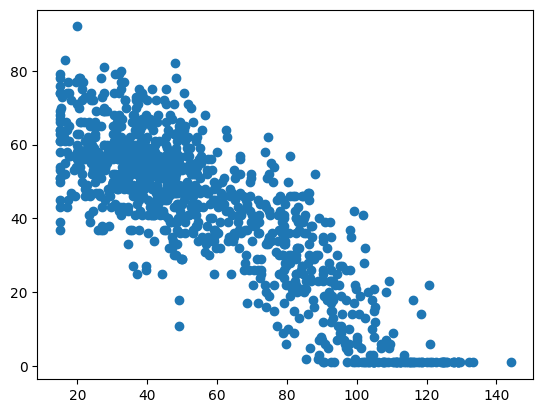

In [55]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])

In [42]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [43]:
scaled_features[:5]


array([[ 0.0061401 ,  0.09745644,  0.76510194],
       [-0.36825649, -0.3051838 , -0.28311966],
       [ 0.08101942,  0.46858571, -0.83218813],
       [ 0.60517466,  0.83971497, -0.63252687],
       [-0.44313581, -0.52576062,  0.76510194]])

In [57]:
scaled_features = pd.DataFrame(scaled_features, columns=['age','income','spend'])

In [58]:
scaled_features.head()

,age,income,spend
0,0.006140,0.097456,0.765102
1,-0.368256,-0.305184,-0.283120
2,0.081019,0.468586,-0.832188
3,0.605175,0.839715,-0.632527
4,-0.443136,-0.525761,0.765102


In [44]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

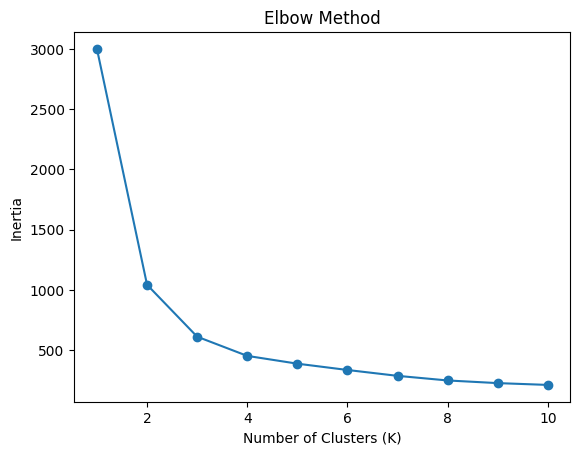

In [45]:
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [46]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(scaled_features)

In [47]:
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1000,M,39.0,59.9,58.0,0
1,1001,M,34.0,48.4,37.0,0
2,1002,F,40.0,70.5,26.0,1
3,1003,F,47.0,81.1,30.0,1
4,1004,F,33.0,42.1,58.0,0


In [48]:
df['Cluster'].value_counts()

Cluster
0    568
1    291
2    141
Name: count, dtype: int64

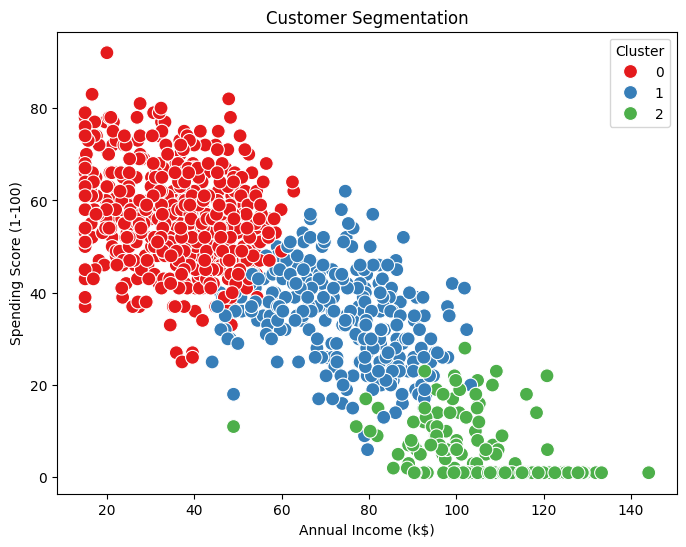

In [49]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set1',
    s=100
)

plt.title('Customer Segmentation')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [50]:
df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,30.445423,36.345599,55.867958
1,42.632302,73.918900,34.731959
2,65.382979,106.112057,5.900709


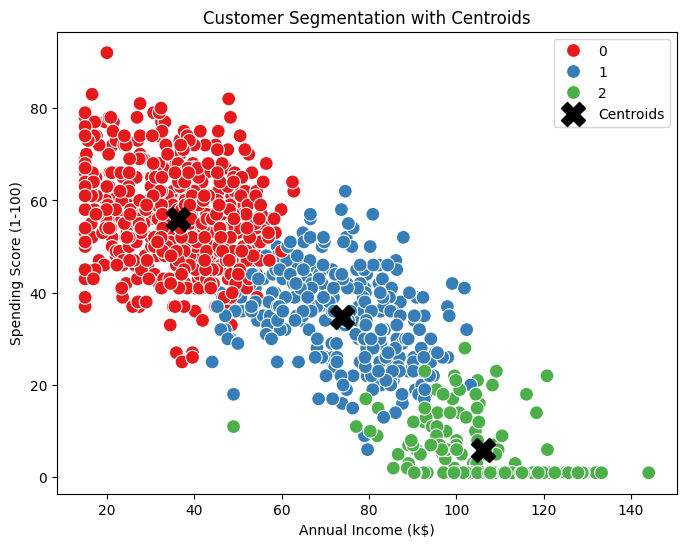

In [51]:
# Get cluster centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# Plot customers
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=100
)

# Plot centroids
plt.scatter(
    centroids[:, 1],
    centroids[:, 2],
    marker='X',
    s=300,
    color='black',
    label='Centroids'
)

plt.title('Customer Segmentation with Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [52]:
x = centroids[:, 1]  # Income
y = centroids[:, 2]  # Spending
y

array([55.86795775, 34.73195876,  5.90070922])

In [53]:
from sklearn.metrics import silhouette_score

In [54]:
score = silhouette_score(scaled_features, df['Cluster'])

print("Silhouette Score:", score)

Silhouette Score: 0.48277454367009137
